<a href="https://colab.research.google.com/github/somnath-alt/Heart_Disease_Prediction-ML-/blob/main/Heart_Diseas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
#import kagglehub
#from kagglehub import KaggleDatasetAdapter

In [2]:
from os.path import exists
#Making a directory
import requests
data_path = Path('Kaggle_data/')
dataset_path = data_path / 'heart.csv'
if data_path.is_dir():
  print(f"{data_path} directory alredy exists.")
else:
  data_path.mkdir(parents=True ,exist_ok = True)
  print(f"{data_path} is created")
with open(data_path/'heart.csv',"wb") as f:
  request = requests.get("https://raw.githubusercontent.com/somnath-alt/Heart_Disease_Prediction-ML-/refs/heads/main/heart.csv")
  print("Downloading the Heart diseas Dataset....")
  f.write(request.content)

Kaggle_data is created


In [3]:
heart_df = pd.read_csv(dataset_path)
heart_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
#Getting Dataset Statistic
heart_df.describe(include='all')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


Processing the data

In [6]:
heart_df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [7]:
#Checking the duplicate
heart_df.duplicated().sum()

np.int64(0)

In [8]:
#Checking Number of unique value in each feature
heart_df.nunique()

,0
Age,50
Sex,2
ChestPainType,4
RestingBP,67
Cholesterol,222
FastingBS,2
RestingECG,3
MaxHR,119
ExerciseAngina,2
Oldpeak,53


Coverting Catagorical Values into Numeric


In [9]:
cat_col = heart_df.select_dtypes(include='object').columns
cat_col

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [10]:
for col in cat_col:
  print(col)
  print(heart_df[col].nunique(),list(range(heart_df[col].nunique())))
  heart_df[col].replace(heart_df[col].unique(),list(range(heart_df[col].nunique())),inplace=True)
  print("*"*90)
  print()

Sex
2 [0, 1]
******************************************************************************************

ChestPainType
4 [0, 1, 2, 3]
******************************************************************************************

RestingECG
3 [0, 1, 2]
******************************************************************************************

ExerciseAngina
2 [0, 1]
******************************************************************************************

ST_Slope
3 [0, 1, 2]
******************************************************************************************



/tmp/ipython-input-762/4048398052.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  heart_df[col].replace(heart_df[col].unique(),list(range(heart_df[col].nunique())),inplace=True)
/tmp/ipython-input-762/4048398052.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heart_df[col].replace(heart_df[c

In [11]:
heart_df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,0,140,289,0,0,172,0,0.0,0,0
1,49,1,1,160,180,0,0,156,0,1.0,1,1
2,37,0,0,130,283,0,1,98,0,0.0,0,0
3,48,1,2,138,214,0,0,108,1,1.5,1,1
4,54,0,1,150,195,0,0,122,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,3,110,264,0,0,132,0,1.2,1,1
914,68,0,2,144,193,1,0,141,0,3.4,1,1
915,57,0,2,130,131,0,0,115,1,1.2,1,1
916,57,1,0,130,236,0,2,174,0,0.0,1,1


In [12]:
heart_df['Cholesterol'].value_counts()

,count
Cholesterol,
0,172
254,11
220,10
223,10
204,9
...,...
353,1
278,1
157,1


In [13]:
heart_df['Cholesterol'].replace(0,np.nan,inplace=True)

/tmp/ipython-input-762/2922871359.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  heart_df['Cholesterol'].replace(0,np.nan,inplace=True)


In [14]:
#Imputing the Cholesterol '0' values with KNN imputer
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=3
                     )
impute_replace = imputer.fit_transform(heart_df)
heart_df = pd.DataFrame(impute_replace,columns=heart_df.columns)

In [15]:
heart_df['Cholesterol'].isna().sum()

np.int64(0)

In [16]:
#checking if there are any '0' values in Cholesterol
count = 0
for i in heart_df['Cholesterol']:
  if i == 0:
    count+=1
print(count)

0


In [17]:
heart_df['RestingBP'].replace(0,np.nan,inplace=True)
imputer = KNNImputer(n_neighbors=3)
impute_replace = imputer.fit_transform(heart_df)
heart_df = pd.DataFrame(impute_replace,columns=heart_df.columns)

/tmp/ipython-input-762/2607716017.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  heart_df['RestingBP'].replace(0,np.nan,inplace=True)


In [18]:
heart_df['RestingBP'].unique()

array([140., 160., 130., 138., 150., 120., 110., 136., 115., 100., 124.,
       113., 125., 145., 112., 132., 118., 170., 142., 190., 135., 180.,
       108., 155., 128., 106.,  92., 200., 122.,  98., 105., 133.,  95.,
        80., 137., 185., 165., 126., 152., 116., 144., 154., 134., 104.,
       139., 131., 141., 178., 146., 158., 123., 102.,  96., 143., 172.,
       156., 114., 127., 101., 174.,  94., 148., 117., 192., 129., 164.])

In [19]:
##Changing the column type to integer expect 'oldpeak'
with_out_old_peak = heart_df.columns
with_out_old_peak = with_out_old_peak.drop('Oldpeak')
heart_df[with_out_old_peak] = heart_df[with_out_old_peak].astype('int32')

In [20]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int32  
 1   Sex             918 non-null    int32  
 2   ChestPainType   918 non-null    int32  
 3   RestingBP       918 non-null    int32  
 4   Cholesterol     918 non-null    int32  
 5   FastingBS       918 non-null    int32  
 6   RestingECG      918 non-null    int32  
 7   MaxHR           918 non-null    int32  
 8   ExerciseAngina  918 non-null    int32  
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    int32  
 11  HeartDisease    918 non-null    int32  
dtypes: float64(1), int32(11)
memory usage: 46.7 KB


Visualizing the data

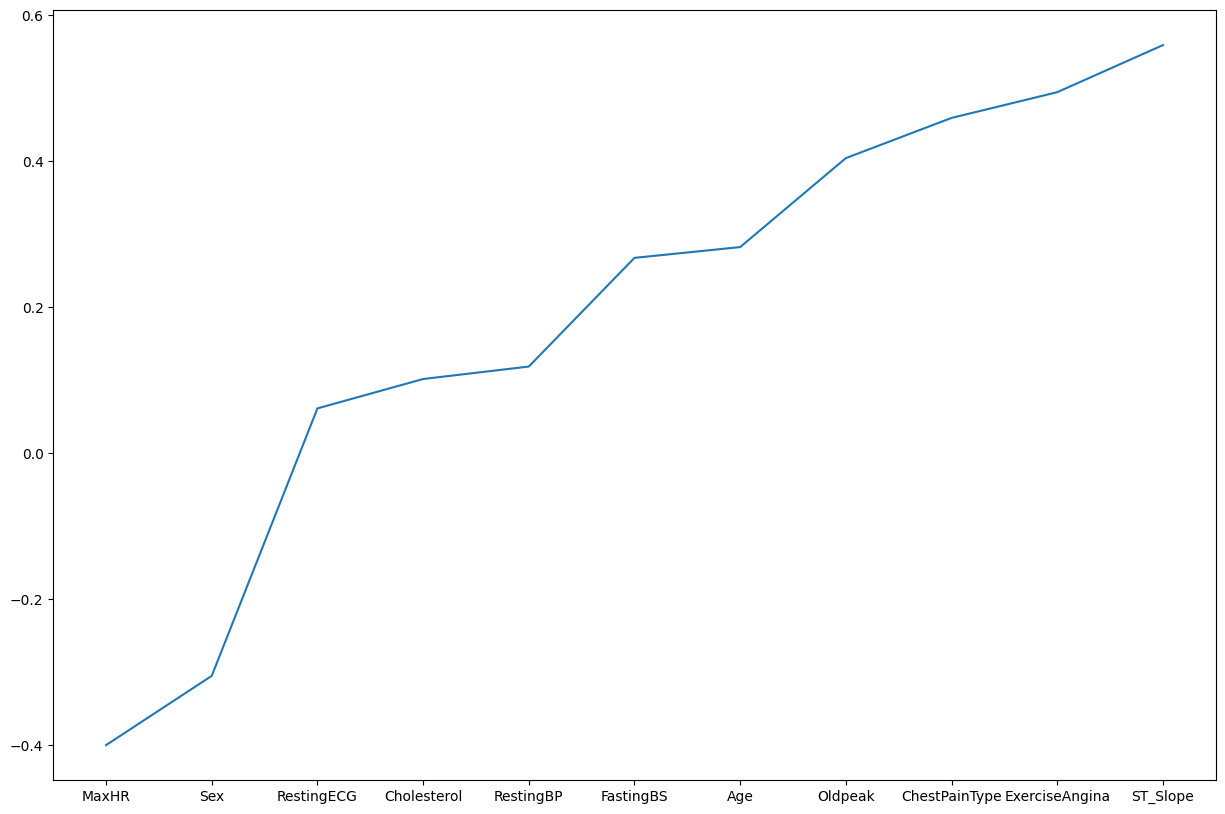

In [21]:
plt.figure(figsize=(15,10))
plt.plot(heart_df.corr()['HeartDisease'][:-1].sort_values())

In [22]:
#Visualizing the correlation
import plotly.express as px
px.line(heart_df.corr()['HeartDisease'][:-1].sort_values())

In [23]:
#Checking the age and heartdisease correlation
px.sunburst(heart_df,path=['HeartDisease','Age'])

In [24]:
px.histogram(heart_df,x='Age',color='HeartDisease')

In [25]:
#Percentage of HeartDisease Data distribution
px.pie(heart_df,names ='HeartDisease',title = 'Percentage of HeartDisease Data distribution')

In [26]:
#Sex and HeartDisease Relation
px.histogram(heart_df,x='Sex',color='HeartDisease')

In [27]:
#FastingBS vs HeartDisease
px.histogram(heart_df,x='FastingBS', color='HeartDisease')

In [30]:
#MaxHR vs HeartDiseas
px.sunburst(heart_df,path=['HeartDisease','MaxHR'])

In [31]:
px.violin(heart_df,x='HeartDisease',y='MaxHR',color='HeartDisease')

In [32]:
#Oldpeak vs HeartDisease
px.violin(heart_df,x='HeartDisease',y='Oldpeak',color='HeartDisease')

ST_Slope vs HeartDiseas

In [33]:
px.histogram(heart_df,x='ST_Slope',color='HeartDisease')

In [36]:
#ExerciseAngina vs HeartDisease
px.histogram(heart_df,x='ExerciseAngina',color='HeartDisease')

Train-Test Split

In [39]:
from sklearn.model_selection import train_test_split
import random
X_train,X_test,y_train,y_test = train_test_split(
                                heart_df.drop('HeartDisease',  axis=1),
                                heart_df['HeartDisease'],
                                test_size=0.2,
                                random_state=42,
                                stratify=heart_df['HeartDisease'])

In [40]:
len(X_train),len(X_test)

(734, 184)

Implementing Logistic Regression Algorithm

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

solver = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
best_solver = ''
test_score = np.zeros(len(solver))

for i, n in enumerate(solver):
    if n == 'lbfgs':
        lr = LogisticRegression(solver=n, max_iter=1000)
    else:
        lr = LogisticRegression(solver=n)
    lr.fit(X_train, y_train)
    test_score[i] = lr.score(X_test, y_test)

    if lr.score(X_test, y_test) == test_score.max():
        best_solver = n

print(best_solver)

lr = LogisticRegression(solver=best_solver)
if best_solver == 'lbfgs':
    lr = LogisticRegression(solver=best_solver, max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print(f'LogisticRegression Score: {accuracy_score(y_test, lr_pred)*100}%')

newton-cholesky
LogisticRegression Score: 85.86956521739131%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Predictions
y_pred = lr.predict(X_test)

# Probabilities
y_prob = lr.predict_proba(X_test)[:, 1]

# Metrics
accuracy = (accuracy_score(y_test, y_pred))*100
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Model Evaluation Metrics:")
print(f"Accuracy   : {accuracy:.4f}%")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1-score   : {f1:.4f}")
print(f"ROC-AUC    : {roc_auc:.4f}")

Model Evaluation Metrics:
Accuracy   : 85.8696%
Precision  : 0.8585
Recall     : 0.8922
F1-score   : 0.8750
ROC-AUC    : 0.9038


In [48]:
import pickle
file = open('LogisticRegression.pkl','wb')
pickle.dump(lr,file)